# **Laboratorium 2** — Podstawowe operacje arytmetyczne w analizie danych

Analiza danych IHME COVID-19 Health Services Disruption Survey (Kenia, Nigeria, RPA, 2020).

### Import wymaganych bibliotek

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Wczytanie danych medycznych

Dane pochodza z ankiety IHME dot. zaklóceń w opiece zdrowotnej w czasie pandemii COVID-19.

In [16]:
df = pd.read_csv("IHME_ORB_C19HSDS_2020_Y2020M12D03.CSV")
df.head()

,SbjNum,NetDuration,InterviewTimeVStart,InterviewTimeVEnd,Date,Srvyr,Country,LANG,R1,R1_5,...,G11_Other,G11_99,FinalOutcome,NumOfVisits,weight_combined,kenya_weight,nigeria_weight,southafrica_weight,agegroup,gk_weight
0,133476254,0:10:14,7/17/2020 13:53,7/17/2020 14:26,7/17/2020 8:53,3232,2,1,9,15.0,...,NaN,NaN,1,1,0.829860,NaN,0.829860,NaN,1,1.555754
1,133281846,0:22:16,7/10/2020 12:53,7/10/2020 14:47,7/10/2020 7:53,3206,2,4,12,22.0,...,NaN,NaN,1,1,1.416946,NaN,1.416946,NaN,2,1.949579
2,133280780,0:19:23,7/10/2020 12:35,7/10/2020 12:54,7/10/2020 7:35,3202,2,3,10,13.0,...,NaN,NaN,1,1,0.883601,NaN,0.883601,NaN,2,2.151458
3,133281834,0:10:11,7/10/2020 10:21,7/10/2020 10:32,7/10/2020 5:21,3212,2,1,12,9.0,...,NaN,NaN,1,1,1.416946,NaN,1.416946,NaN,2,2.325065
4,133491249,0:09:59,7/18/2020 8:27,7/18/2020 8:39,7/18/2020 3:27,3225,2,3,11,28.0,...,NaN,NaN,1,1,0.829860,NaN,0.829860,NaN,1,1.640484


Do analizy wybieramy kolumny liczbowe:
- **R1_5** — wiek respondenta (lata),
- **R17**, **R18** — liczba osób w gospodarstwie domowym wg kategorii (do korelacji i kowariancji),
- **NumOfVisits** — liczba wizyt w placówkach ochrony zdrowia.

Usuwamy braki danych przed obliczeniami statystycznymi.

In [17]:
wiek = df["R1_5"].dropna()
r17 = df["R17"].dropna()
r18 = df["R18"].dropna()
print("Liczba obserwacji (wiek):", len(wiek))
print("Liczba obserwacji (R17, R18):", len(r17), len(r18))

Liczba obserwacji (wiek): 1016
Liczba obserwacji (R17, R18): 242 3057


## 1. Średnia arytmetyczna (Mean)

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

Określa przeciętną wartość cechy — tu: średni wiek respondentów.

In [18]:
np.max(wiek)

np.float64(45.0)

In [19]:
np.min(wiek)

np.float64(9.0)

In [20]:
srednia_wiek = np.mean(wiek)
print("Średni wiek respondenta:", round(srednia_wiek, 2), "lat")

Średni wiek respondenta: 27.38 lat


## 2. Mediana (Median)

Wartość środkowa w uporządkowanym zbiorze. Odporna na wartości odstające — przydatna gdy rozkład wieku jest skośny.

In [21]:
len(wiek)

1016

In [22]:
mediana_wiek = np.median(wiek)
print("Mediana wieku:", mediana_wiek, "lat")

Mediana wieku: 28.0 lat


## 3. Odchylenie standardowe (Standard Deviation)

$$\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

Mówi, jak bardzo wiek respondentów odchyla się od średniej — miara zróżnicowania próby.

In [23]:
odch_std = np.std(wiek)
print("Odchylenie standardowe wieku:", round(odch_std, 2))

Odchylenie standardowe wieku: 10.08


## 4. Wariancja (Variance)

$$\mathrm{Var}(X) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2 = \sigma^2$$

In [24]:
wariancja = np.var(wiek)
print("Wariancja wieku:", round(wariancja, 2))

Wariancja wieku: 101.67


## 5. Korelacja (Correlation)

$$\rho_{X,Y} = \frac{\mathrm{Cov}(X,Y)}{\sigma_X \sigma_Y}$$

Sprawdzamy związek między dwiema cechami gospodarstwa domowego respondenta (kolumny **R17** i **R18**). Wartość bliska 1 oznacza silną dodatnią zależność liniową.

In [25]:
pary = df[["R17", "R18"]].dropna()
korelacja = np.corrcoef(pary["R17"], pary["R18"])[0, 1]
print("Współczynnik korelacji Pearsona (R17, R18):", round(korelacja, 4))

Współczynnik korelacji Pearsona (R17, R18): 0.476


## 6. Kowariancja (Covariance)

$$\mathrm{Cov}(X,Y) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

Mierzy wspólne zmienianie się dwóch zmiennych. Znak (+/−) wskazuje kierunek związku.

In [26]:
kowariancja = np.cov(pary["R17"], pary["R18"])
print("Macierz kowariancji:")
print(kowariancja)

Macierz kowariancji:
[[78.24347588 37.66969583]
 [37.66969583 80.0281369 ]]


### Weryfikacja: korelacja policzona ręcznie z kowariancji

$$\rho = \frac{\mathrm{Cov}(X,Y)}{\sqrt{\mathrm{Var}(X)}\cdot\sqrt{\mathrm{Var}(Y)}}$$

In [27]:
korelacja_recznie = kowariancja[0, 1] / (np.sqrt(kowariancja[0, 0]) * np.sqrt(kowariancja[1, 1]))
print("Korelacja (z kowariancji):", round(korelacja_recznie, 4))
print("Korelacja (np.corrcoef):  ", round(korelacja, 4))

Korelacja (z kowariancji): 0.476
Korelacja (np.corrcoef):   0.476


## Podsumowanie

Przeprowadzona analiza pokazuje:
- Średni wiek respondenta i mediana są zbliżone — rozkład wieku jest dość symetryczny.
- Odchylenie standardowe świadczy o umiarkowanym zróżnicowaniu wieku w próbie.
- Współczynnik korelacji między R17 a R18 jest dodatni — gospodarstwa o większej liczbie osób w jednej kategorii mają też więcej osób w drugiej.
- Kowariancja potwierdza kierunek zależności, a wyliczona z niej korelacja jest identyczna z `np.corrcoef`, co potwierdza poprawność obliczeń.

### Wizualizacja rozkładu wieku

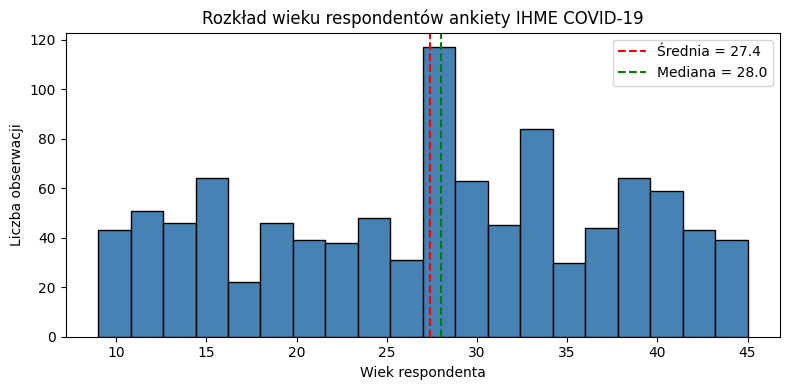

In [28]:
plt.figure(figsize=(8, 4))
plt.hist(wiek, bins=20, color="steelblue", edgecolor="black")
plt.axvline(srednia_wiek, color="red", linestyle="--", label=f"Średnia = {srednia_wiek:.1f}")
plt.axvline(mediana_wiek, color="green", linestyle="--", label=f"Mediana = {mediana_wiek:.1f}")
plt.xlabel("Wiek respondenta")
plt.ylabel("Liczba obserwacji")
plt.title("Rozkład wieku respondentów ankiety IHME COVID-19")
plt.legend()
plt.tight_layout()
plt.show()